<div style = "color:green; font-size:25px">The objective of this project is to analyze superstore sales using EDA and find out the factors affecting sales.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pandas import Series, DataFrame
from datetime import datetime


<h2 style = "color:green">1. Loading Data

In [2]:
data = pd.read_csv('/home/kartika/Datasets/superstoredataset.csv', encoding = 'ISO-8859-1')
data.head(10)




,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680
5,6,CA-2015-115812,9/6/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,9/6/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,9/6/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,9/6/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,9/6/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


<h2 style = "color:green">2. Handaling Missing and Duplicate values

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [17]:
data.isnull().sum()


Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

In [30]:
data = data.dropna(subset = ['Postal_Code'])

<div style = "color:green; font-size:20px">Since, out of 9800 entries, there are only 11 missing values in postal_code, we used dropna.

In [30]:
data.duplicated().sum()

np.int64(0)

<div style = "color:green; font-size:20px">No duplicate values.

In [31]:
data.describe()

,Row_ID,Postal_Code,Sales
count,9789.000000,9789.000000,9789.000000
mean,4896.705588,55273.322403,230.116193
std,2827.486899,32041.223413,625.302079
min,1.000000,1040.000000,0.444000
25%,2449.000000,23223.000000,17.248000
50%,4896.000000,58103.000000,54.384000
75%,7344.000000,90008.000000,210.392000
max,9800.000000,99301.000000,22638.480000


<div>

<h2 style = "color:green">3. Converting data values to suitable format

In [3]:
data['Order_Date'] = pd.to_datetime(data['Order_Date'], format = '%d/%m/%Y')
data['Ship_Date'] = pd.to_datetime(data['Ship_Date'], format = '%d/%m/%Y')

In [14]:
print(data['Order_Date'].iloc[:5])

0   2017-11-08
1   2017-11-08
2   2017-06-12
3   2016-10-11
4   2016-10-11
Name: Order_Date, dtype: datetime64[ns]


<div style = "color:green; font-size:20px">The dates in order and ship column are in string, we converted them to datetime object for graphs and plotting.

<h2 style = "color:green">4. Univariate Analysis

<h3 style = "color:green">4.1 Sales 

In [31]:
data['Sales'].describe()

count     9789.000000
mean       230.116193
std        625.302079
min          0.444000
25%         17.248000
50%         54.384000
75%        210.392000
max      22638.480000
Name: Sales, dtype: float64

In [32]:
data['Sales'].skew()

np.float64(13.053630955201138)

<div style = "color:green; font-size:20px">Since skewness is 13, the sales data is heavily positively skewed. Sales from most of the customers are low to medium, but few sales from very few number of customers is very high.

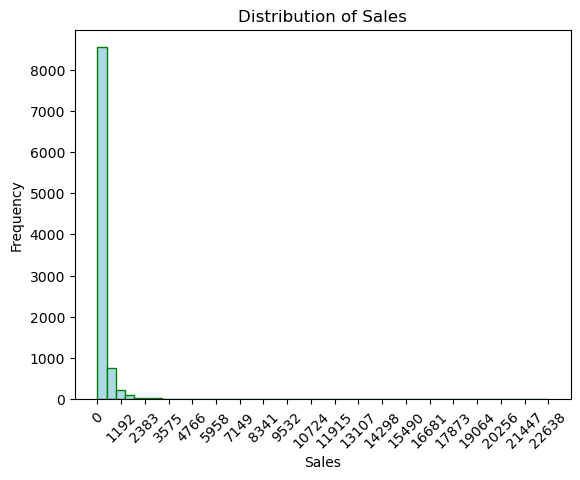

In [13]:
bins = np.linspace(data['Sales'].min(), data['Sales'].max(), 50)
plt.hist(data['Sales'], bins = bins, color='lightblue', edgecolor='green')


plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.xticks(np.linspace(data['Sales'].min(), data['Sales'].max(), 20), rotation=45)
plt.title('Distribution of Sales')
plt.show()

<div style = "color:green; font-size:20px">From the hist plot, we can observe the sales data is heavily right skewed. Sales from majority of customers are in the range of 0-2000 and sales from only few number of customers are extremely hight.

<h3 style="color:green">4.2 